# Matrix Spaces and Rank

A computational companion to [Matrix Spaces and Rank](https://fjhickernell.github.io/MATH332Fall2026/slides/08-matrix-spaces-and-rank.html). Use one rectangular matrix to compute all four fundamental spaces, compatibility certificates, and the factorization $\mathsf{A}=\mathsf{C}\mathsf{R}$.

The deck supplies the mathematical exposition. Predict each result before running its cell; use exact SymPy calculations to check your reasoning. Numerical plots illustrate the examples rather than prove general statements.

## Running this notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/08-matrix-spaces-and-rank.ipynb)

Run all cells in order with the **qmcpy** kernel. The setup cell changes the environment only in Colab, where it installs the course's recorded `classlib` checkout. It leaves the working directory unchanged. Colab does not save edits to the course repository; save a copy in Drive to retain your experiments.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "--recursive", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
import matplotlib.pyplot as plt
import classlib as cl
from IPython.display import display, Markdown

%matplotlib inline
cl.nbviz.init(use_tex=False)
sp.init_printing()
np.set_printoptions(precision=5, suppress=True)
colors = [cl.nbviz.TOL_BRIGHT["blue"], cl.nbviz.TOL_BRIGHT["red"]]
t = sp.symbols("t", real=True)

def show(label, value):
    display(Markdown(label))
    display(value)


## 1. One reduction exposes the structure

Use the deck's $3\times4$ matrix. Compute its RREF and rank, then extract $\mathsf{C}$ from the original pivot columns and $\mathsf{R}$ from the nonzero RREF rows. In this topic $\mathsf{R}$ is the rank-factorization coefficient matrix, not a PLU factor.

A

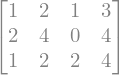

rref(A)

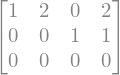

C: original pivot columns

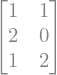

R: nonzero RREF rows

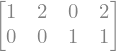

Rank 2; nullity 2; left nullity 1


Exact factorization residual A-CR

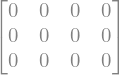

In [3]:
A = Matrix([[1,2,1,3], [2,4,0,4], [1,2,2,4]])
reduced, pivots = A.rref()
r = len(pivots)
m,n = A.shape
C = A[:,list(pivots)]
R = reduced[:r,:]
show("A", A)
show("rref(A)", reduced)
show("C: original pivot columns", C)
show("R: nonzero RREF rows", R)
print(f"Rank {r}; nullity {n-r}; left nullity {m-r}")
assert A == C*R and R[:,list(pivots)] == sp.eye(r)
show("Exact factorization residual A-CR", A-C*R)


## 2. The four fundamental spaces

Column and left-null vectors live in $\mathbb R^3$; row and null vectors live in $\mathbb R^4$. Represent each basis as columns, including the transposed nonzero rows of $\mathsf R$. Check the two orthogonal pairs exactly.

Write these spaces as $\operatorname{col}(A)$, $\operatorname{row}(A)$, $\operatorname{null}(A)$, and $\operatorname{null}(A^{\mathsf T})$. Transposing exchanges rows and columns, so

$$\operatorname{col}(A)=\operatorname{row}(A^{\mathsf T}),\qquad\operatorname{row}(A)=\operatorname{col}(A^{\mathsf T}).$$

Here row-space vectors are represented as columns. The next cell checks the two equalities by checking that the combined bases have the same rank.


Column space (R^3): basis vectors are columns

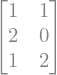

Row space (R^4): basis vectors are columns

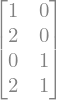

Null space (R^4): basis vectors are columns

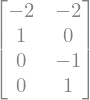

Left null space (R^3): basis vectors are columns

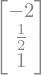

Row/null orthogonality

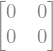

Column/left-null orthogonality

col(A) = row(A.T): combined basis rank

row(A) = col(A.T): combined basis rank

In [4]:
column_basis = C
row_basis = R.T
null_basis = Matrix.hstack(*A.nullspace())
left_null_basis = Matrix.hstack(*A.T.nullspace())
for label,basis in [("Column space (R^3)",column_basis), ("Row space (R^4)",row_basis),
                    ("Null space (R^4)",null_basis), ("Left null space (R^3)",left_null_basis)]:
    show(f"{label}: basis vectors are columns",basis)
show("Row/null orthogonality",row_basis.T*null_basis)
show("Column/left-null orthogonality",column_basis.T*left_null_basis)
assert A*null_basis == sp.zeros(m,n-r)
assert A.T*left_null_basis == sp.zeros(n,m-r)
assert row_basis.T*null_basis == sp.zeros(r,n-r)
assert column_basis.T*left_null_basis == sp.zeros(r,m-r)
assert row_basis.rank()+null_basis.rank() == n
assert column_basis.rank()+left_null_basis.rank() == m

row_basis_of_transpose = Matrix.hstack(*(v.T for v in A.T.rowspace()))
column_basis_of_transpose = Matrix.hstack(*A.T.columnspace())
assert column_basis.row_join(row_basis_of_transpose).rank() == r
assert row_basis.row_join(column_basis_of_transpose).rank() == r
show("col(A) = row(A.T): combined basis rank", r)
show("row(A) = col(A.T): combined basis rank", r)


## 3. Attainable right-hand sides and all solutions

Test the deck's $b=(1,2,1)^{\mathsf T}$ and $b=(0,1,0)^{\mathsf T}$. A nonzero left-null dot product certifies inconsistency. For the consistent case, combine one particular solution with the null-space basis to produce every solution.

Right-hand side

Left-null compatibility test

Solution set

Right-hand side

Left-null compatibility test

Solution set

All solutions of the consistent system

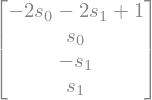

In [5]:
b_good, b_bad = Matrix([1,2,1]), Matrix([0,1,0])
for b in (b_good,b_bad):
    show("Right-hand side",b)
    show("Left-null compatibility test",left_null_basis.T*b)
    show("Solution set",sp.linsolve((A,b)))
assert left_null_basis.T*b_good == sp.zeros(m-r,1)
assert left_null_basis.T*b_bad != sp.zeros(m-r,1)
x_particular = Matrix([1,0,0,0])
parameters = Matrix(sp.symbols(f"s0:{n-r}",real=True))
x_general = x_particular+null_basis*parameters
show("All solutions of the consistent system",x_general)
assert A*x_general == b_good
assert sp.linsolve((A,b_bad)) == sp.EmptySet


### Picture the column space and a rejected right-hand side

The column-space basis spans a plane in $\mathbb R^3$. Plot it with the two right-hand sides. Use a numerical least-squares projection only for the drawing; the exact left-null test above is the compatibility certificate.

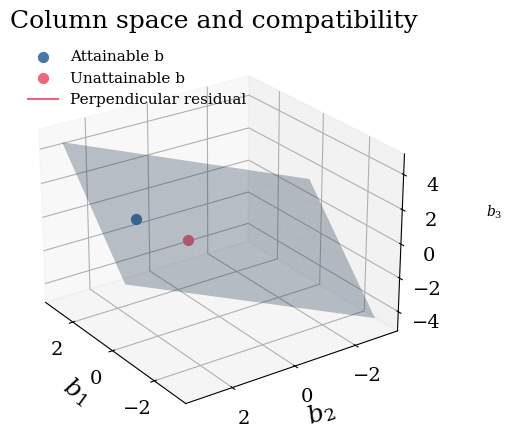

In [6]:
C_numeric = np.array(C,dtype=float)
b_numeric = np.array(b_bad,dtype=float).ravel()
coordinate_fit = np.linalg.lstsq(C_numeric,b_numeric,rcond=None)[0]
projection = C_numeric@coordinate_fit
residual = b_numeric-projection
assert np.allclose(C_numeric.T@residual,0)
mesh = np.linspace(-1.5,1.5,15)
ss,tt = np.meshgrid(mesh,mesh)
plane = C_numeric[:,0,None,None]*ss+C_numeric[:,1,None,None]*tt
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111,projection="3d")
ax.plot_surface(*plane,alpha=0.3,color=colors[0])
for b,label,color in [(np.array(b_good,dtype=float).ravel(),"Attainable b",colors[0]),
                       (b_numeric,"Unattainable b",colors[1])]:
    ax.scatter(*b,s=50,color=color,label=label)
segment = np.vstack([projection,b_numeric])
ax.plot(*segment.T,color=colors[1],label="Perpendicular residual")
ax.set(xlabel=r"$b_1$",ylabel=r"$b_2$",zlabel="",title="Column space and compatibility")
ax.view_init(elev=25,azim=145)
ax.text2D(1.18,0.55,r"$b_3$",transform=ax.transAxes)
ax.legend(loc="upper left",fontsize=11)
fig.subplots_adjust(left=0.04,right=0.83,bottom=0.08,top=0.88)
plt.show()


## 4. What the coefficient factor does

For any input $x$, $\mathsf Rx$ gives the coordinates of $\mathsf Ax$ in the ordered column-space basis supplied by $\mathsf C$. Check this for one input, then verify that the null spaces of $\mathsf A$ and $\mathsf R$ agree.

Coordinates Rx

Output Ax reconstructed as C(Rx)

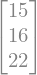

R and A have the same null space: C has independent columns.


In [7]:
x = Matrix([2,-1,3,4])
output_coordinates = R*x
show("Coordinates Rx",output_coordinates)
show("Output Ax reconstructed as C(Rx)",C*output_coordinates)
assert C*output_coordinates == A*x
assert R*null_basis == sp.zeros(r,n-r)
assert R.rank() == A.rank()
print("R and A have the same null space: C has independent columns.")


## 5. An abstract map becomes a matrix

For differentiation $D:\mathbb P_2\to\mathbb P_1$, use input basis $(1,t,t^2)$ and output basis $(1,t)$. Build the matrix by applying $D$ to each basis polynomial and recording the output coordinates. Check $p=2-3t+5t^2$.

Matrix of differentiation

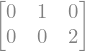

Output coordinates

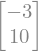

Reconstructed derivative

In [8]:
input_basis = (sp.Integer(1),t,t**2)
derivative_matrix = Matrix.hstack(*(Matrix([sp.diff(poly,t).coeff(t,j) for j in range(2)]) for poly in input_basis))
p = 2-3*t+5*t**2
p_coordinates = Matrix([2,-3,5])
dp_coordinates = derivative_matrix*p_coordinates
dp_reconstructed = dp_coordinates[0]+dp_coordinates[1]*t
show("Matrix of differentiation",derivative_matrix)
show("Output coordinates",dp_coordinates)
assert sp.expand(dp_reconstructed-sp.diff(p,t)) == 0
show("Reconstructed derivative",dp_reconstructed)


## Your experiments

1. Replace `A` with the deck's exercise matrix $\begin{bmatrix}1&2&0\\0&0&1\\1&2&1\end{bmatrix}$. Repeat the rank factorization and four-space calculations. Update the right-hand sides to have the correct dimension.
2. Construct three attainable right-hand sides as `A*x`. Find their coordinates in `C`, then add a nonzero left-null vector to each. Explain why the altered right-hand sides fail compatibility.
3. Build the matrix of evaluation $T(p)=(p(0),p(1))^{\mathsf T}$ on $\mathbb P_2$. Check it on the polynomial in Section 5 and identify its null space.

Return to the deck for the general rank, orthogonality, and coordinate-map arguments. Use original pivot columns for a column-space basis, and nonzero reduced rows for a row-space basis.

In [9]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 7.0 sec.
